<h1 style="font-size:34px; text-align:center; color: green; font-weight:bold; margin-bottom:5px;">
  HERBAL STORE ANALYTICS
</h1>

<h2 style="font-size:24px; text-align: center; font-weight:bold; color: #34A99D;">
 RFM CHURN PREDICTION MODEL
</h2>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, roc_curve, auc
import joblib  

In [15]:
df = pd.read_csv('../data/sales.csv')

In [16]:
df.columns

Index(['Unnamed: 0', 'order_id', 'order_date', 'variant_sku', 'product_qty',
       'subtotal_price', 'discount', 'tax', 'total_price', 'customer_id',
       'first_name', 'last_name', 'fullname', 'phone_number', 'email_id',
       'city', 'state', 'country', 'postal_code', 'variant_price',
       'cost_per_item', 'variant_inventory_qty', 'true_sku_margins',
       'product_name', 'category', 'year', 'month', 'day', 'weekday',
       'revenue', 'profit', 'discount_rate', 'margin_pct', 'date',
       'profit_margin', 'season'],
      dtype='str')

In [18]:
df['order_date'] = pd.to_datetime(df['order_date'])

snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

In [19]:
customer_df = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'nunique',                                   # Frequency
    'revenue': 'sum',                                        # Monetary
    'profit': 'sum',
    'discount_rate': 'mean',
    'product_qty': 'sum'
}).reset_index()

In [20]:
customer_df.columns = [
    'customer_id', 'recency', 'frequency', 'monetary',
    'profit', 'avg_discount', 'total_qty'
]

In [22]:
customer_df['churn'] = customer_df['recency'].apply(
    lambda x: 1 if x > 60 else 0   # 60 days inactive = churn
)

**TRAIN MODEL**

In [23]:
features = ['recency', 'frequency', 'monetary', 'profit', 'avg_discount', 'total_qty']
X = customer_df[features]
y = customer_df['churn']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [26]:
y_pred = model.predict(X_test)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       212
           1       0.74      0.89      0.81        28

    accuracy                           0.95       240
   macro avg       0.86      0.93      0.89       240
weighted avg       0.96      0.95      0.95       240



In [29]:
confusion_matrix(y_test, y_pred)

array([[203,   9],
       [  3,  25]])

In [30]:
roc_auc_score(y_test, y_pred)

0.9252021563342316

In [31]:
y_prob = model.predict_proba(X_test)[:, 1]

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

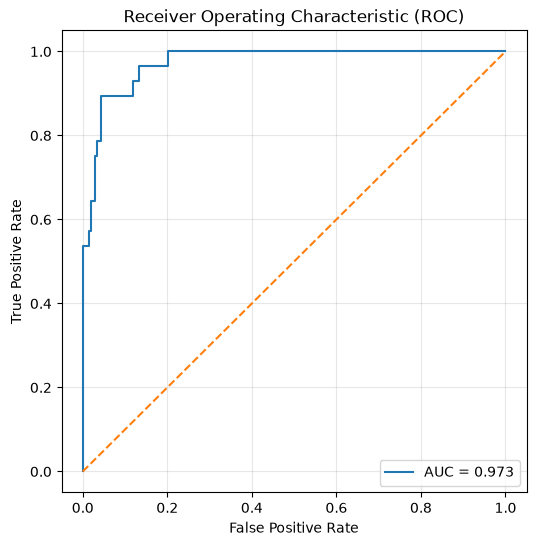

In [36]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

The model achieved an ROC-AUC score of 0.973, demonstrating excellent ability to distinguish between positive and negative classes. The ROC curve remains close to the upper-left corner, indicating a high true positive rate with a low false positive rate across different classification thresholds. Combined with 95% accuracy and an 89% recall for the minority class, the model shows strong predictive performance and robust generalization.